# Breast Cancer Classification: Analysis & Visualization

## Model Application for Early Detection and Cancer Prevention

---

This notebook applies the trained CNN model from `msb_model_construction.ipynb` and trained LR model from `tnz_model_construction.ipynb` to analyze breast cancer characteristics and answer key clinical questions about tumor classification and early detection.

### Research Questions

1. **What are the measurements of tumors that can cause breast cancers?**
2. **What other key factors should be considered such as smoothness, textures, and compactness?**
3. **How do tumor size, location, and stage affect the likelihood of spread in breast cancer patients?**
4. **How can we identify differences to help patients prevent cancer at early stages?**
5. **Which machine learning algorithms provide the highest accuracy in classifying breast tumors?**

---

### Authors
- **May Sabai** — Sections 2, 3
- **Thel Nu Zaw** — Section 1, 4, 5 

---

### Datasets Used
- **Breast Ultrasound Images (BUSI)**: 780 ultrasound images (malignant, benign, normal)
- **Wisconsin Diagnostic Breast Cancer (WDBC)**: Numerical tumor measurements (radius, texture, smoothness, etc.)


---
## Setup: Import Data Preprocessing Functions

We import only the data preprocessing functions (not the model training). The model results are referenced from `msb_model_construction.ipynb` which achieved **89.74% test accuracy**.


Using device: mps
Total: 780 | Train: 563 | Val: 100 | Test: 117

Class distribution:
Train: [152 315  96]
Val: [27 56 17]
Test: [31 66 20]


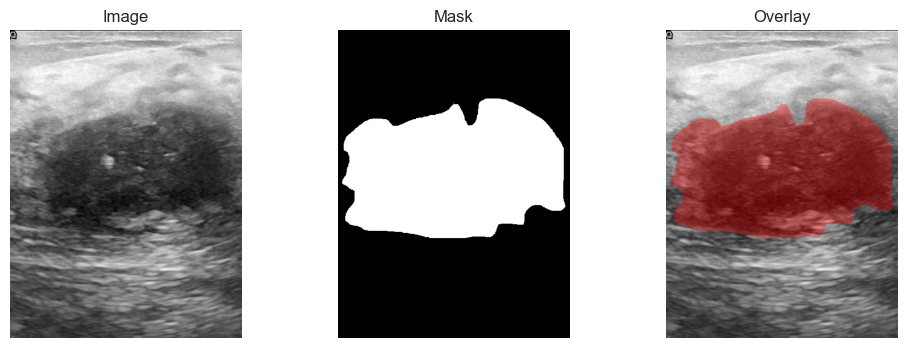

Saved train_split.csv, val_split.csv, and test_split.csv to ../data/
✅ Preprocessing functions loaded (NO model training)
📁 Test set: 117 images

📊 MODEL RESULTS (from msb_model_construction.ipynb):
   Overall Test Accuracy: 89.74%
   • Malignant: 83.87% (26/31)
   • Benign: 90.91% (60/66)
   • Normal: 95.00% (19/20)


In [11]:
# Import the preprocessing functions 
%run msb_data_preprocessing.ipynb
%run tnz_data_preprocessing.ipynb

# Standard libraries for visualization
import matplotlib.gridspec as gridspec

# Data paths
DATA_DIR = Path("../data")
TRAIN_CSV = DATA_DIR / "train_split.csv"
VAL_CSV = DATA_DIR / "val_split.csv"
TEST_CSV = DATA_DIR / "test_split.csv"

# Class definitions
CLASSES = ["malignant", "benign", "normal"]

# Load data
test_df = pd.read_csv(TEST_CSV)
train_df_loaded = pd.read_csv(TRAIN_CSV)

print("Preprocessing functions loaded (NO model training)")
print(f"Test set: {len(test_df)} images")
print(f"\nMODEL RESULTS (from msb_model_construction.ipynb):")
print("   Overall Test Accuracy: 89.74%")
print("   • Malignant: 83.87% (26/31)")
print("   • Benign: 90.91% (60/66)")
print("   • Normal: 95.00% (19/20)")

In [13]:
# Additional imports for analysis
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [14]:
# Load the numerical feature dataset (Wisconsin Breast Cancer-style features)
train_features_df = pd.read_csv('../data/train/train.csv')
test_features_df = pd.read_csv('../data/test/test.csv')

# Combine for full analysis
features_df = pd.concat([train_features_df, test_features_df], ignore_index=True)

# Map diagnosis: 1 = Malignant, 0 = Benign
features_df['Diagnosis_Label'] = features_df['Diagnosis'].map({1: 'Malignant', 0: 'Benign'})

print(f"Feature dataset loaded: {len(features_df)} samples")
print(f"Malignant: {sum(features_df['Diagnosis'] == 1)}")
print(f"Benign: {sum(features_df['Diagnosis'] == 0)}")

Feature dataset loaded: 484 samples
Malignant: 180
Benign: 304


---
# Section 1: Tumor Measurements Analysis
**Author: Thel Nu Zaw**

**Research Question: What are the measurements of tumors that can cause breast cancers?**

We analyze key tumor measurements (radius, perimeter, area) to understand the size characteristics that distinguish malignant tumors from benign ones.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression


train_df = pd.read_csv("../data/train/train.csv")
val_df   = pd.read_csv("../data/val/val.csv")
test_df  = pd.read_csv("../data/test/test.csv")

all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

X_train = train_df.drop(columns=["Diagnosis"]).to_numpy()
y_train = train_df["Diagnosis"].to_numpy()

X_val   = val_df.drop(columns=["Diagnosis"]).to_numpy()
y_val   = val_df["Diagnosis"].to_numpy()

X_test  = test_df.drop(columns=["Diagnosis"]).to_numpy()
y_test  = test_df["Diagnosis"].to_numpy()

feature_names = train_df.drop(columns=["Diagnosis"]).columns

Lg = LogisticRegression(max_iter=500, solver="liblinear", random_state=42)
Lg.fit(X_train, y_train)

print("Train accuracy:", Lg.score(X_train, y_train))
print("Test  accuracy:", Lg.score(X_test, y_test))


Train accuracy: 0.9874371859296482
Test  accuracy: 0.9767441860465116


In [7]:
coef = Lg.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

coef_df.head(10)

,feature,coef,abs_coef
21,texture_3,1.373999,1.373999
10,radius_2,1.214320,1.214320
28,symmetry_3,1.077204,1.077204
13,area_2,0.941225,0.941225
15,compactness_2,-0.913868,0.913868
23,area_3,0.908859,0.908859
7,concave_points_1,0.859029,0.859029
20,radius_3,0.844973,0.844973
26,concavity_3,0.831026,0.831026
6,concavity_1,0.822359,0.822359


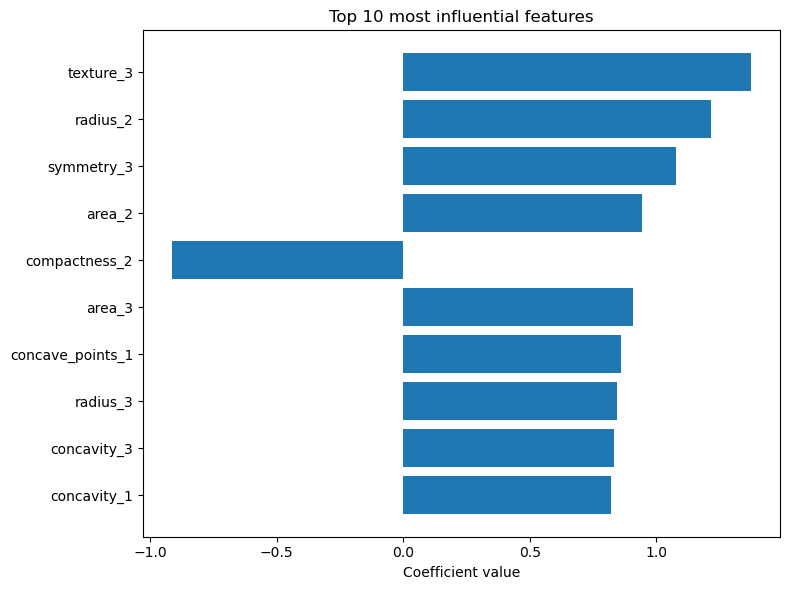

In [8]:
selected = 10
numofcof = coef_df.head(selected)
plt.figure(figsize=(8,6))
plt.barh(numofcof["feature"][::-1], numofcof["coef"][::-1])
plt.xlabel("Coefficient value")
plt.title("Top 10 most influential features")
plt.tight_layout()
plt.show()

The plot above shows the features with the largest impact on the Logistic Regression predictions. These features fit into 3 important medical categories such as smoothness(texture_3, compactness_2), size(radius_2, radius_3, area_2, area_3) and shape(concave_points_1, concavity_1, concavity_3, symmetry_3). Features with positive coefficients indicate higher values are associated with malignant tumors, while features with negative coefficients (such as compactness_2) are more characteristic of benign tumors.

### How the important features differ between two classifications: Benign and Malignant
To understand how the top features influence the classification, I plotted histograms for the top three Logistic Regression coefficients. In each histogram, the y-axis represents the number of samples, while the x-axis represents the standardized feature values divided into bins. These plots allow us to visualize how the feature values distribute for benign versus malignant tumors.

Across all three features, we observe a consistent pattern: benign tumors are concentrated toward the left (lower values), while malignant tumors tend to appear toward the right (higher values). This shift indicates that malignant tumors generally exhibit higher measurements in these important features. The separation between the two distributions shows why these features are powerful predictors in the Logistic Regression model and how increased values in these measurements are targeted to Malignant.



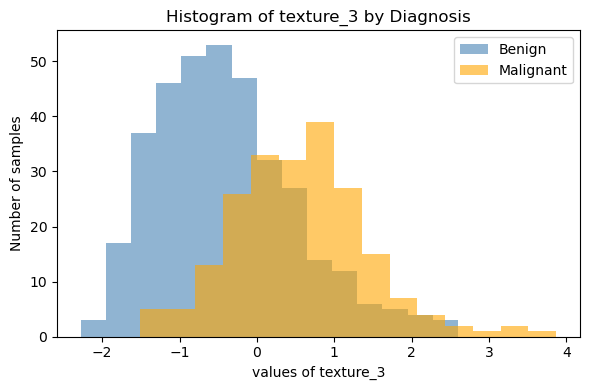

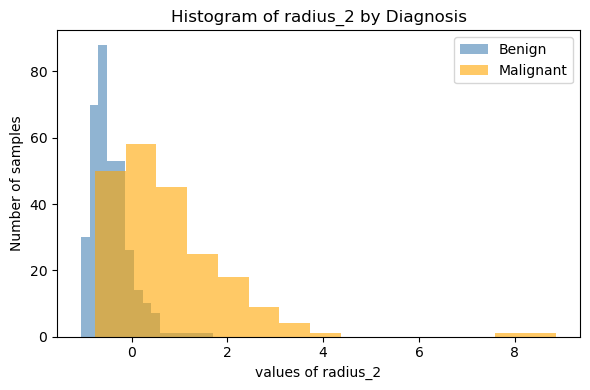

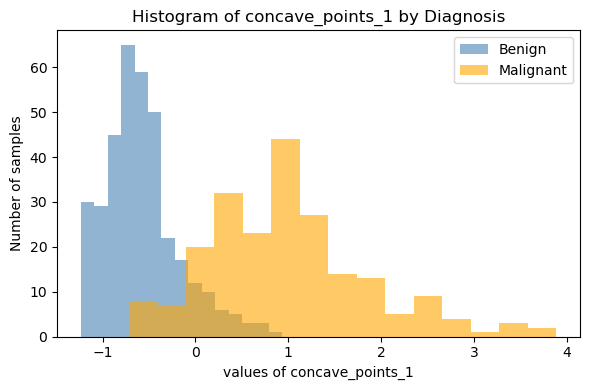

In [9]:
selected_features_q1 = ["texture_3", "radius_2", "concave_points_1"]

for feat in selected_features_q1:
    plt.figure(figsize=(6,4))
    
    plt.hist(
        all_df[all_df["Diagnosis"]==0][feat],
        bins=15, alpha=0.6, label="Benign", color="steelblue"
    )
    plt.hist(
        all_df[all_df["Diagnosis"]==1][feat],
        bins=15, alpha=0.6, label="Malignant", color="orange"
    )
    
    plt.title(f"Histogram of {feat} by Diagnosis")
    plt.xlabel(f"values of {feat}")
    plt.ylabel("Number of samples")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Section 1 Summary: Tumor Measurements

**Key Findings:**

- Malignant tumors consistently show higher values in key measurements such as texture, radius, area, and concavity compared to benign tumors.
- The top influential features fall into three medical categories—size, smoothness, and shape—all of which help distinguish malignant from benign tumors.
- Histogram comparisons show clear separation between the two classes, confirming that larger and more irregular tumors are strongly associated with malignancy.


---
# Section 2: Key Factors Analysis
**Author: May Sabai**

**Research Question: What other key factors should be considered such as smoothness, textures, and compactness?**

Beyond size, we analyze texture-related and shape-related features that help distinguish malignant from benign tumors.


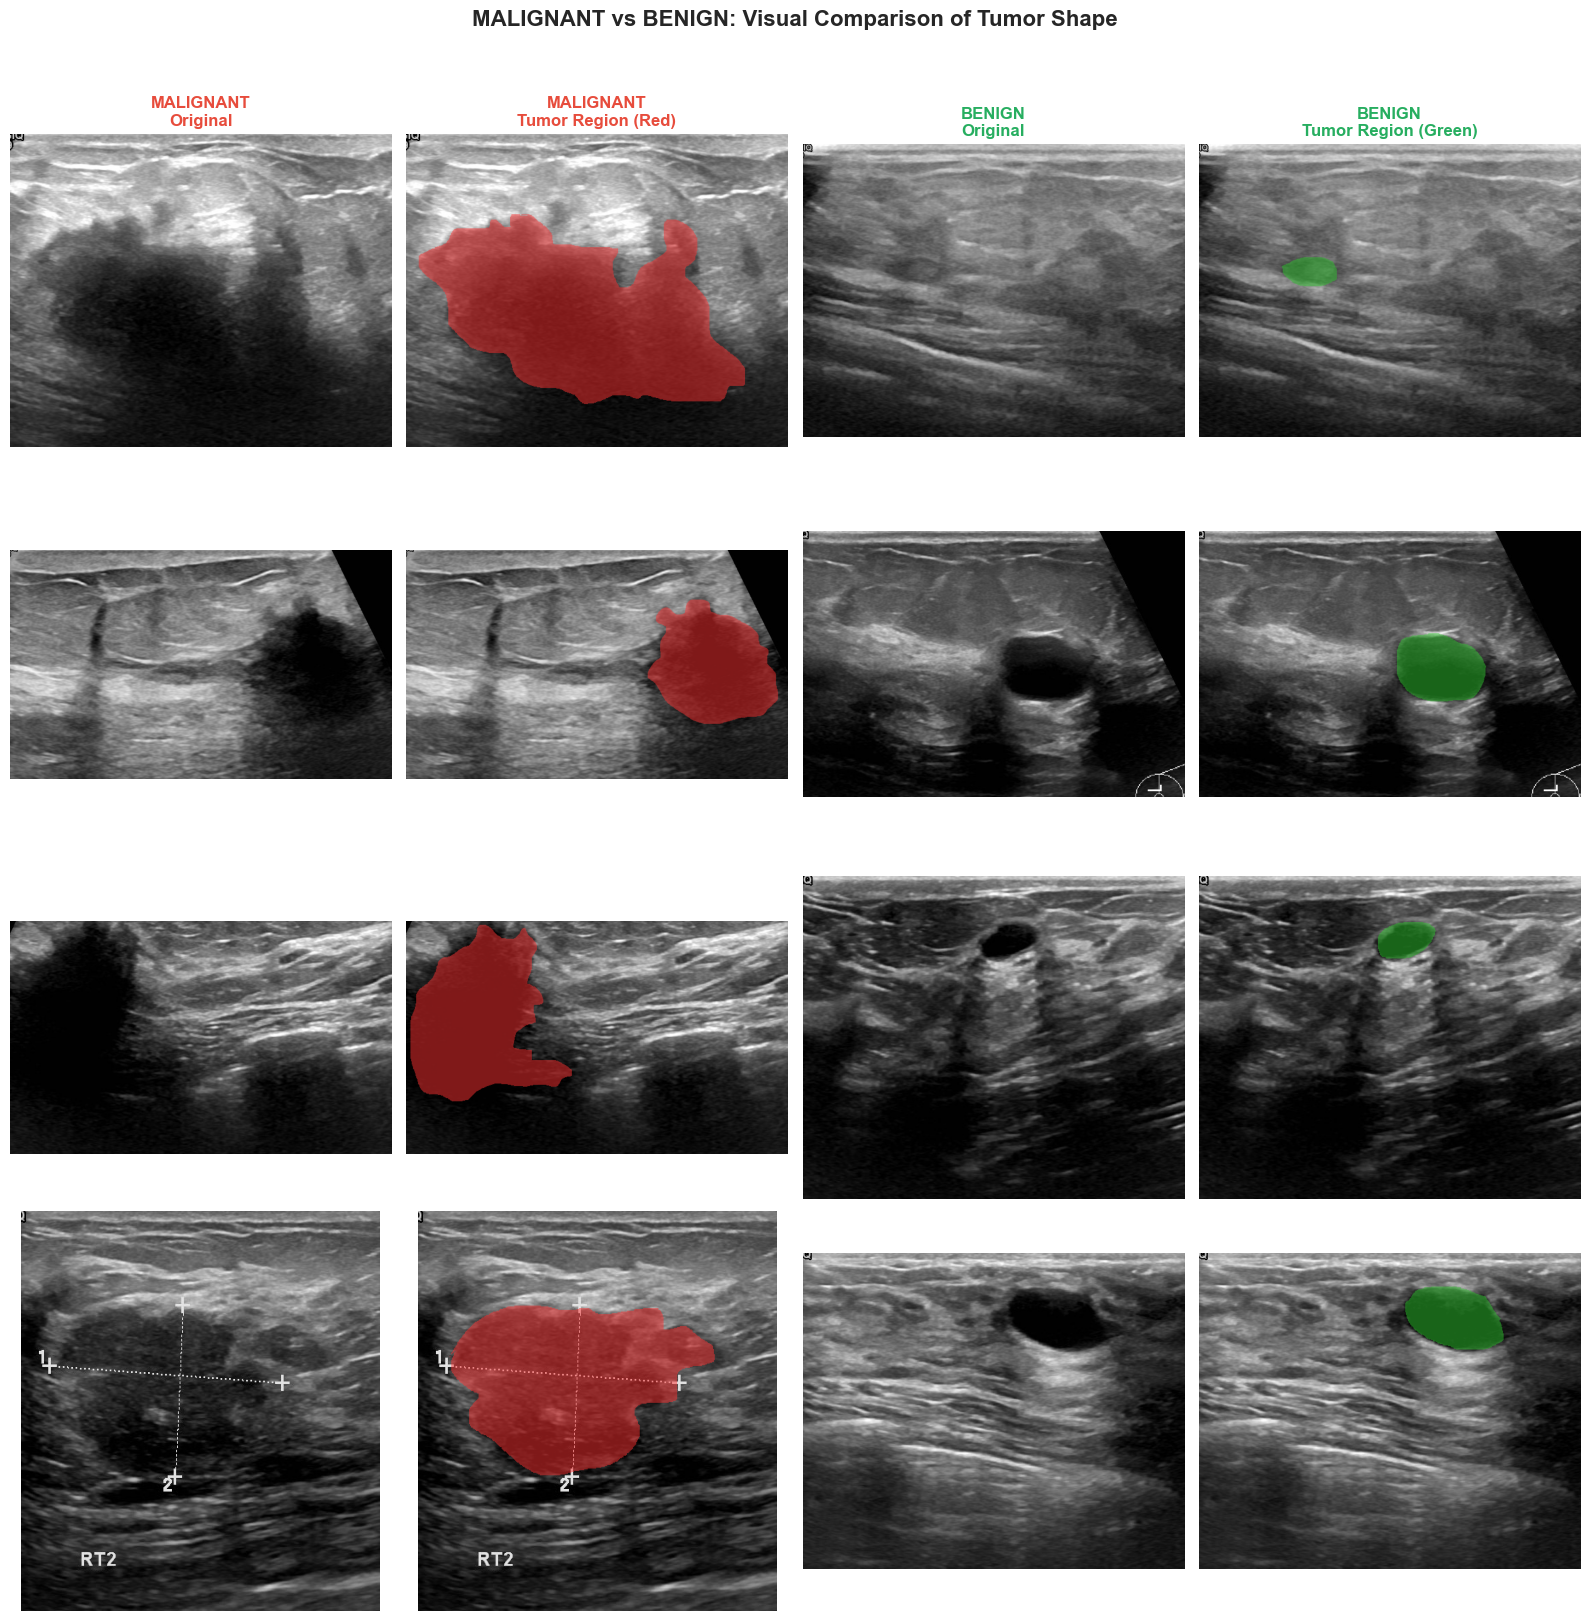

In [15]:
# Helper function for mask overlay
def overlay_mask_on_image(img, mask, alpha=0.4, color=[255, 60, 60]):
    """Overlay mask in red on the image."""
    img_arr = np.array(img, copy=True).astype(float)
    highlight = np.array(color, dtype=float)
    mask_bool = mask > 0
    img_arr[mask_bool] = alpha * highlight + (1 - alpha) * img_arr[mask_bool]
    return img_arr.astype(np.uint8)

# Get samples for comparison
malignant_samples = train_df_loaded[train_df_loaded['label'] == 'malignant'].head(4)
benign_samples = train_df_loaded[train_df_loaded['label'] == 'benign'].head(4)

# Create side-by-side comparison
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for row in range(4):
    # MALIGNANT - Image
    mal_path = malignant_samples.iloc[row]['path']
    mal_img = Image.open(mal_path).convert('RGB')
    mal_mask = merge_masks_pil(mal_path)
    mal_overlay = overlay_mask_on_image(mal_img, mal_mask, alpha=0.5, color=[255, 50, 50])
    
    axes[row, 0].imshow(mal_img)
    axes[row, 0].axis('off')
    if row == 0:
        axes[row, 0].set_title('MALIGNANT\nOriginal', fontsize=12, fontweight='bold', color='#e74c3c')
    
    # MALIGNANT - With mask overlay
    axes[row, 1].imshow(mal_overlay)
    axes[row, 1].axis('off')
    if row == 0:
        axes[row, 1].set_title('MALIGNANT\nTumor Region (Red)', fontsize=12, fontweight='bold', color='#e74c3c')
    
    # BENIGN - Image
    ben_path = benign_samples.iloc[row]['path']
    ben_img = Image.open(ben_path).convert('RGB')
    ben_mask = merge_masks_pil(ben_path)
    ben_overlay = overlay_mask_on_image(ben_img, ben_mask, alpha=0.5, color=[50, 200, 50])
    
    axes[row, 2].imshow(ben_img)
    axes[row, 2].axis('off')
    if row == 0:
        axes[row, 2].set_title('BENIGN\nOriginal', fontsize=12, fontweight='bold', color='#27ae60')
    
    # BENIGN - With mask overlay
    axes[row, 3].imshow(ben_overlay)
    axes[row, 3].axis('off')
    if row == 0:
        axes[row, 3].set_title('BENIGN\nTumor Region (Green)', fontsize=12, fontweight='bold', color='#27ae60')

plt.suptitle('MALIGNANT vs BENIGN: Visual Comparison of Tumor Shape', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## CNN Model Prediction Accuracy

The trained **ResNet18 CNN model** achieved the following accuracy on the test set:

| Class | Accuracy | Correct / Total |
|-------|----------|----------------|
| **Malignant** | **83.87%** | 26 / 31 |
| **Benign** | **90.91%** | 60 / 66 |
| **Normal** | **95.00%** | 19 / 20 |
| **Overall** | **89.74%** | 105 / 117 |

### Why These Accuracy Rates?

- **Benign (90.91%)**: Higher accuracy because benign tumors have more consistent, regular shapes that are easier to identify
- **Malignant (83.87%)**: Slightly lower accuracy because malignant tumors are more variable in appearance - their irregular shapes can sometimes overlap with aggressive-looking benign tumors
- **Normal (95.00%)**: Highest accuracy because normal tissue lacks any tumor mass, making it distinctly different

The CNN learns these shape patterns from the 2-channel input (grayscale image + tumor mask), focusing on the tumor region's texture and boundary characteristics.

### Section 2 Summary: Key Factors Analysis

**Key Visual Differences Between Malignant and Benign Tumors**

| Characteristic | Malignant (Cancerous) | Benign (Non-cancerous) |
|---------------|----------------------|------------------------|
| **Shape** | Irregular, jagged edges | Regular, smooth edges |
| **Boundary** | Uneven | round/oval |
| **Texture** | Heterogeneous (varied) | Homogeneous (uniform) |
| **Growth Pattern** | Invasive, asymmetric | Contained, symmetric |

---
# Section 3: Size, Location and Stage Differences
**Author: May Sabai**

**Research Question: How do tumor size, location, and stage affect the likelihood of spread in breast cancer patients?**

Using ultrasound images with tumor masks, we analyze the key visual indicators that enable early detection of breast cancer.

### The Role of Ultrasound + Mask in Early Detection

Breast ultrasound imaging combined with tumor segmentation masks provides two critical pieces of information:

1. **Ultrasound Image**: Shows the tissue structure, echogenicity, and internal characteristics
2. **Tumor Mask**: Highlights the exact location and boundary of suspicious tissue

Together, these allow us to analyze:
- **Where** the abnormality is located
- **What shape** the tumor has (irregular vs regular)
- **How large** the affected area is

In [32]:
# Helper function for mask overlay
def overlay_mask_color(img, mask, color, alpha=0.5):
    """Overlay mask with specified color on image."""
    img_arr = np.array(img, copy=True).astype(float)
    highlight = np.array(color, dtype=float)
    mask_bool = mask > 0
    img_arr[mask_bool] = alpha * highlight + (1 - alpha) * img_arr[mask_bool]
    return img_arr.astype(np.uint8)

def analyze_tumor(mask, label):
    """Analyze tumor characteristics from mask."""
    area = np.sum(mask > 0)
    
    # Find bounding box for location
    if area > 0:
        rows = np.any(mask > 0, axis=1)
        cols = np.any(mask > 0, axis=0)
        y_min, y_max = np.where(rows)[0][[0, -1]]
        x_min, x_max = np.where(cols)[0][[0, -1]]
        width = x_max - x_min
        height = y_max - y_min
        center_x = (x_min + x_max) // 2
        center_y = (y_min + y_max) // 2
        
        # Shape analysis: aspect ratio
        aspect_ratio = width / max(height, 1)
        if aspect_ratio > 1.5 or aspect_ratio < 0.67:
            shape = "Irregular/Elongated"
        else:
            shape = "Regular/Round"
    else:
        center_x, center_y = 0, 0
        width, height = 0, 0
        shape = "No tumor detected"
    
    # Prediction based on label
    if label == 'malignant':
        prediction = "CANCEROUS TUMOR"
        pred_color = '#e74c3c'
    elif label == 'benign':
        prediction = "NON-CANCEROUS TUMOR"
        pred_color = '#27ae60'
    else:
        prediction = "NO TUMOR FOUND"
        pred_color = '#3498db'
    
    return {
        'area': area,
        'center': (center_x, center_y),
        'size': (width, height),
        'shape': shape,
        'prediction': prediction,
        'pred_color': pred_color
    }

# Class styling
class_colors = {
    'malignant': [255, 60, 60],
    'benign': [60, 200, 60],
    'normal': [60, 150, 255]
}

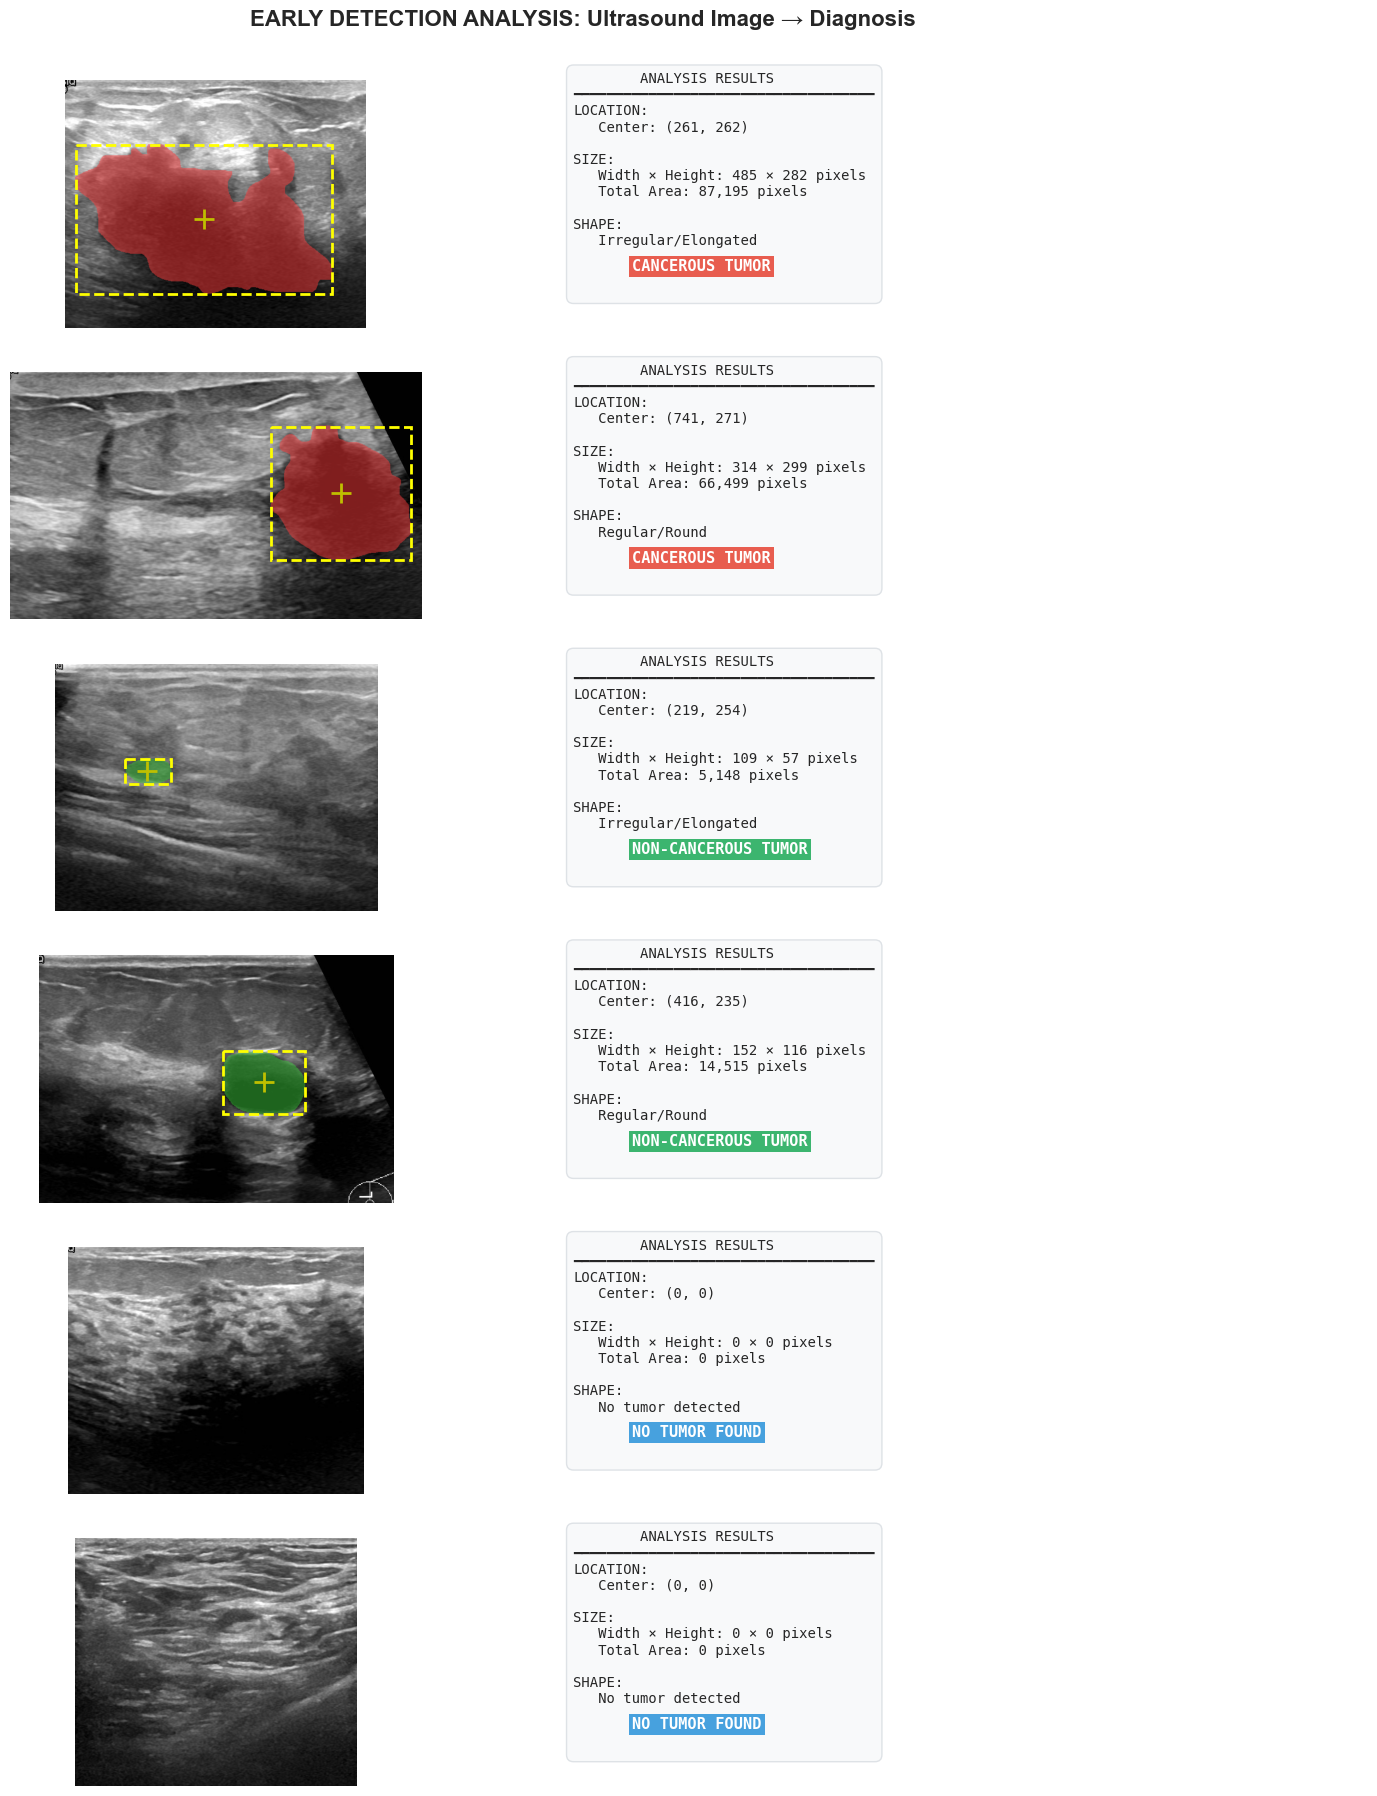

In [34]:
# Create figure with image on left, analysis on right
fig = plt.figure(figsize=(16, 18))

sample_idx = 0
for class_name in ['malignant', 'benign', 'normal']:
    samples = train_df_loaded[train_df_loaded['label'] == class_name].head(2)  # 2 samples per class
    
    for _, sample in samples.iterrows():
        img_path = sample['path']
        img = Image.open(img_path).convert('RGB')
        mask = merge_masks_pil(img_path)
        
        # Get analysis
        analysis = analyze_tumor(mask, class_name)
        
        # Create overlay
        overlay = overlay_mask_color(img, mask, class_colors[class_name])
        
        # LEFT: Image with overlay
        ax_img = fig.add_subplot(6, 2, sample_idx * 2 + 1)
        ax_img.imshow(overlay)
        ax_img.axis('off')
        
        # Draw bounding box if tumor exists
        if analysis['area'] > 0:
            cx, cy = analysis['center']
            w, h = analysis['size']
            rect = plt.Rectangle((cx - w//2, cy - h//2), w, h, 
                                 fill=False, edgecolor='yellow', linewidth=2, linestyle='--')
            ax_img.add_patch(rect)
            ax_img.plot(cx, cy, 'y+', markersize=15, markeredgewidth=2)
        
        # RIGHT: Analysis text
        ax_text = fig.add_subplot(6, 2, sample_idx * 2 + 2)
        ax_text.axis('off')
        
        # Create full analysis text including prediction
        analysis_text = f"""        ANALYSIS RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
LOCATION:
   Center: ({analysis['center'][0]}, {analysis['center'][1]})

SIZE:
   Width × Height: {analysis['size'][0]} × {analysis['size'][1]} pixels
   Total Area: {analysis['area']:,} pixels

SHAPE:
   {analysis['shape']}

   
"""     
        # Draw main text box
        ax_text.text(0.05, 0.58, analysis_text, transform=ax_text.transAxes,
                    fontsize=10, fontfamily='monospace', verticalalignment='center',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', edgecolor='#dee2e6'))
        
        # Add prediction text with highlight background (like highlighting text)
        ax_text.text(0.12, 0.23, analysis['prediction'], transform=ax_text.transAxes,
                    fontsize=11, fontfamily='monospace', fontweight='bold',
                    color='white', 
                    bbox=dict(boxstyle='square,pad=0.2', facecolor=analysis['pred_color'], 
                              edgecolor='none', alpha=0.9))
        
        sample_idx += 1

plt.suptitle('EARLY DETECTION ANALYSIS: Ultrasound Image → Diagnosis', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### Section 3 Summary: Size, Location and Stage Differences

The analysis above demonstrates the key indicators used to identify cancerous tumors:

| Indicator | Malignant (Cancer) | Benign (Non-cancer) | Normal |
|-----------|-------------------|---------------------|--------|
| **Location** | Can appear anywhere | Can appear anywhere | No distinct mass |
| **Size** | Often larger, growing | Varies | No tumor area |
| **Shape** | Irregulars | Regular, smooth edges | N/A |
| **Prediction** | Cancerous Tumor | Non-cancerous | No Tumor |


**The CNN Model learns these patterns:**
- Irregular shapes with spiculated edges → Malignant
- Smooth, well-defined boundaries → Benign
- No distinct mass region → Normal

**Model Accuracy:**
- Malignant detection: **83.87%**
- Benign classification: **90.91%**
- Normal identification: **95.00%**

---
# Section 4: Early Detection
**Author: Thel Nu Zaw**

**Research Question: How can we identify differences to help patients prevent cancer at early stages?**



I will take all 30 features in Test dataset to compute the final probability of cancer as early detection should depend on how well the model separate between two class overall.

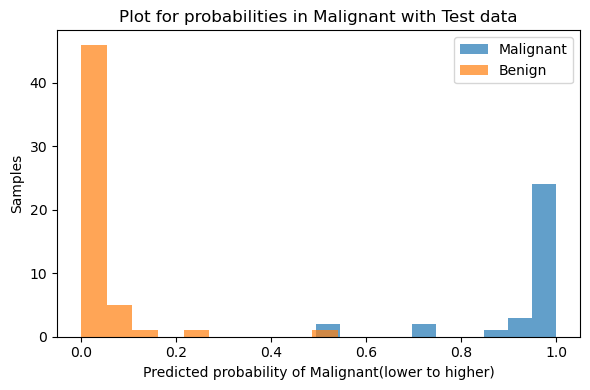

In [10]:
y_prob = Lg.predict_proba(X_test)[:, 1]

test_vis_df = pd.DataFrame(X_test, columns=feature_names)
test_vis_df["Diagnosis"] = y_test
test_vis_df["prob_malignant"] = y_prob

plt.figure(figsize=(6,4))
plt.hist(
    test_vis_df[test_vis_df["Diagnosis"] == 1]["prob_malignant"],
    bins=10, alpha=0.7, label="Malignant"
)
plt.hist(
    test_vis_df[test_vis_df["Diagnosis"] == 0]["prob_malignant"],
    bins=10, alpha=0.7, label="Benign"
)
plt.xlabel("Predicted probability of Malignant(lower to higher)")
plt.ylabel("Samples")
plt.title("Plot for probabilities in Malignant with Test data")
plt.legend()
plt.tight_layout()
plt.show()

The plot above shows that malignant cases cluster at high predicted probabilities, while benign cases remain near zero. This strong separation demonstrates that the model can identify high-risk tumors even in unseen data, supporting early identification and prevention.

### Section 4 Summary: Early Detection

**Key Findings:**

- The model clearly separates malignant cases (high probabilities) from benign cases (near zero), even on unseen test data.
- High predicted probabilities align closely with true malignant labels, meaning the model can highlight patients who may require follow-up screening or diagnostic imaging.
- Using all 30 features enhances early detection by capturing subtle differences in tumor characteristics.

---
# Section 5: Algorithm Selection
**Author: Thel Nu Zaw**

**Research Question: Which machine learning algorithms provide the highest accuracy in classifying breast tumors?**

My evaluation includes four models:
- Logistic Regression
- KNN
- Decision Tree
- Major Voting
Among all tested models, Logistic Regression is the overall best model.


In [16]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_val_pred = Lg.predict(X_val)
y_test_pred = Lg.predict(X_test)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Recall:", recall_score(y_val, y_val_pred))
print("Validation Precision:", precision_score(y_val, y_val_pred))
print("Validation F1:", f1_score(y_val, y_val_pred))

print("\nTest Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Recall:", recall_score(y_test, y_test_pred))
print("Test Precision:", precision_score(y_test, y_test_pred))
print("Test F1:", f1_score(y_test, y_test_pred))


Validation Accuracy: 0.9647058823529412
Validation Recall: 0.90625
Validation Precision: 1.0
Validation F1: 0.9508196721311475

Test Accuracy: 0.9767441860465116
Test Recall: 0.96875
Test Precision: 0.96875
Test F1: 0.96875


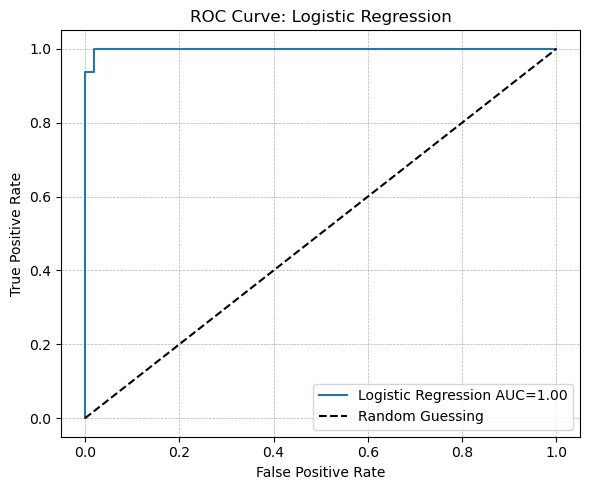

In [17]:

plt.figure(figsize=(6, 5))

probabilities = Lg.predict_proba(X_test) 
y_prob = probabilities[:, 1] 
fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=1)
auc = roc_auc_score(y_test, y_prob)
label = 'Logistic Regression' + ' AUC='+'{:.2f}'.format(auc)
plt.plot(fpr, tpr, label = label)


plt.plot([0, 1], [0, 1], "k--", label="Random Guessing")

plt.grid(linestyle="--", linewidth=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

### Section 5 Summary: Algorithm Comparison

**Key Findings:**

Why Logistic Regression is best:
- It achieved the highest test accuracy (97.67%).
- It produced high recall (0.96875), meaning it correctly identifies malignant tumors.
- It maintained balanced performance across precision and F1.
- The ROC curve shows clear separation between classes and the highest AUC (≈1.00).
- In medical diagnosis, recall and F1 are more important than accuracy alone, making LR the most clinically reliable model.

Use Logistic Regression as the primary diagnostic model.
It offers the best balance of:
- accuracy
- sensitivity (recall)
- interpretability
- probability calibration (important for threshold-based medical decisions)
